# Golden Power Network Analysis

**Case Study: EU Regulation 2019/452 ("Golden Power")**

The central argument is that the EuroVoc classification system — the EU's official subject taxonomy — obscures the true functional relationships between laws, and that citation-based network analysis reveals a more meaningful legislative architecture.

In [77]:
# Import all required libraries
import pandas as pd
import numpy as np
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from itertools import combinations
from collections import Counter
from networkx.algorithms import community

import warnings
warnings.filterwarnings('ignore')

---
## Part 1: Analysis of the Problem

In this section, we analyze how traditional classification systems (EuroVoc) fragment functionally related legislation across multiple administrative domains.

### 1.1 Data Loading and Network Extraction

**Network extraction:** The notebook loads pre-processed node/edge CSVs and extracts the ego-network of the Golden Power regulation (CELEX 32019R0452). It finds 39 connected laws linked by 40 direct citation edges. The edge weights come from a column final_weight (renamed to hybrid_thematic_weight), suggesting an earlier pipeline blended citation and thematic similarity signals.

In [78]:
# Load data
proc_path = os.path.join('..', 'data', 'processed')
nodes_cleaned = pd.read_csv(os.path.join(proc_path, 'nodes_cleaned.csv'))
edges_weighted = pd.read_csv(os.path.join(proc_path, 'edges_weighted.csv'))
concepts_df = pd.read_csv(os.path.join(proc_path, 'eurovoc_concepts_cleaned.csv'))

# Create concept dictionary
concept_dict = dict(zip(concepts_df['id'].astype(str), concepts_df['label']))

# Rename weight column for consistency with the rest of the notebook
edges_weighted.rename(columns={'final_weight': 'hybrid_thematic_weight'}, inplace=True)

# Define seed regulation (Golden Power)
seed_celex = '32019R0452'
seed_id = seed_celex

# Extract Golden Power ego-network (nodes)
connections = edges_weighted[(edges_weighted['source'] == seed_id) | (edges_weighted['target'] == seed_id)]
neighbor_ids = set(connections['source']) | set(connections['target'])
golden_power_network = nodes_cleaned[nodes_cleaned['celex'].isin(neighbor_ids)]

# Filter edges to only those between ego-network nodes
edges_ego = edges_weighted[
    edges_weighted['source'].isin(neighbor_ids) &
    edges_weighted['target'].isin(neighbor_ids)
].copy()

# Canonical names used by downstream cells
nodes_golden_power = golden_power_network.copy()
edges_golden_power = edges_ego

print(f"Golden Power Network:")
print(f"  • Connected laws: {len(golden_power_network)}")
print(f"  • Direct connections to GP: {len(connections)}")
print(f"  • Edges within ego-network: {len(edges_ego)}")

Golden Power Network:
  • Connected laws: 39
  • Direct connections to GP: 40
  • Edges within ego-network: 105


### 1.2 Distribution of the Network (Bar Chart)

**Problem**: The Golden Power framework is fragmented across 15+ EuroVoc domains, obscuring its thematic unity.

In [79]:
# Official EuroVoc top-level domains (21 fields)
EUROVOC_DOMAINS = {
    "AGRICULTURE, FORESTRY AND FISHERIES",
    "AGRI-FOODSTUFFS",
    "BUSINESS AND COMPETITION",
    "ECONOMICS",
    "EDUCATION AND COMMUNICATIONS",
    "EMPLOYMENT AND WORKING CONDITIONS",
    "ENERGY",
    "ENVIRONMENT",
    "EUROPEAN UNION",
    "FINANCE",
    "GEOGRAPHY",
    "GOVERNMENT AND PUBLIC SECTOR",
    "HEALTH",
    "INDUSTRY",
    "INFORMATION AND INFORMATION PROCESSING",
    "INTERNATIONAL ORGANISATIONS",
    "INTERNATIONAL RELATIONS",
    "LAW",
    "POLITICS",
    "PRODUCTION, TECHNOLOGY AND RESEARCH",
    "SCIENCE",
    "SOCIAL QUESTIONS",
    "TRADE",
    "TRANSPORT",
}

def parse_domains(domains_str):
    if pd.isna(domains_str) or str(domains_str).strip() == '':
        return []
    domains = [d.strip() for d in str(domains_str).split(';') if d.strip()]
    cleaned = [re.sub(r'^\d+\s+', '', d).strip().upper() for d in domains]
    # Keep only recognised EuroVoc top-level domains
    return [d for d in cleaned if d in EUROVOC_DOMAINS]

# Count domain frequencies — only EuroVoc-valid entries
domain_counts = Counter()
for domains_str in golden_power_network['domains'].dropna():
    parsed = parse_domains(domains_str)
    domain_counts.update(parsed)

if not domain_counts:
    print("WARNING: No EuroVoc domains matched. Check that 'domains' column "
          "uses the standard EuroVoc top-level names.")
else:
    top_domains = domain_counts.most_common(15)
    domains = [d[0] for d in top_domains]
    counts  = [d[1] for d in top_domains]

    fig = go.Figure(data=[
        go.Bar(
            x=counts,
            y=domains,
            orientation='h',
            marker=dict(
                color=counts,
                colorscale='Viridis',
                showscale=True,
                colorbar=dict(title='Laws')
            )
        )
    ])

    fig.update_layout(
        title='<b>Domain Distribution in Golden Power Network</b><br>'
              '<sub>Top 15 EuroVoc Domains (official taxonomy only)</sub>',
        xaxis_title='Number of Laws',
        yaxis_title='EuroVoc Domain',
        height=600,
        width=900,
        template='plotly_white',
        yaxis={'categoryorder': 'total ascending'}
    )

    fig.show()

    print(f"\nMatched {sum(counts)} domain assignments across "
          f"{len(domain_counts)} distinct EuroVoc domains.")
    print(f"Top 3: {domains[-1]} ({counts[-1]}), "
          f"{domains[-2]} ({counts[-2]}), {domains[-3]} ({counts[-3]})")

    # Also show what got filtered out
    raw_counts = Counter()
    for domains_str in golden_power_network['domains'].dropna():
        raw = [re.sub(r'^\d+\s+', '', d).strip().upper()
               for d in str(domains_str).split(';') if d.strip()]
        raw_counts.update(raw)

    filtered_out = {k: v for k, v in raw_counts.items()
                if k not in EUROVOC_DOMAINS}

    if filtered_out:
        top5 = dict(sorted(filtered_out.items(), key=lambda x: -x[1])[:5])
        print(f"\nFiltered out {len(filtered_out)} non-EuroVoc values "
              f"(top 5): {top5}")


Matched 96 domain assignments across 16 distinct EuroVoc domains.
Top 3: INDUSTRY (1), ENVIRONMENT (1), ECONOMICS (1)

Filtered out 5 non-EuroVoc values (top 5): {'PRIMARY LAW': 9, 'PREPARATORY ACTS': 3, 'INTERNATIONAL AGREEMENTS': 2, 'SECONDARY LEGISLATION': 1, 'COMPLEMENTARY LAW': 1}


Domain bar chart: Counts how many of the 39 laws fall into each of the 21 official EuroVoc top-level domains. The key finding: a single regulation touches 16 distinct domains. 96 domain assignments are spread thinly — the top 3 domains (Industry, Environment, Economics) each have only 1 law. This is the "fragmentation" argument: EuroVoc scatters functionally related legislation across administrative silos.

### 1.3 Confusion Matrix: Domain Overlaps

**Problem**: EuroVoc domains are not "silos" - over 60% of laws have multiple domain assignments, creating ambiguity.

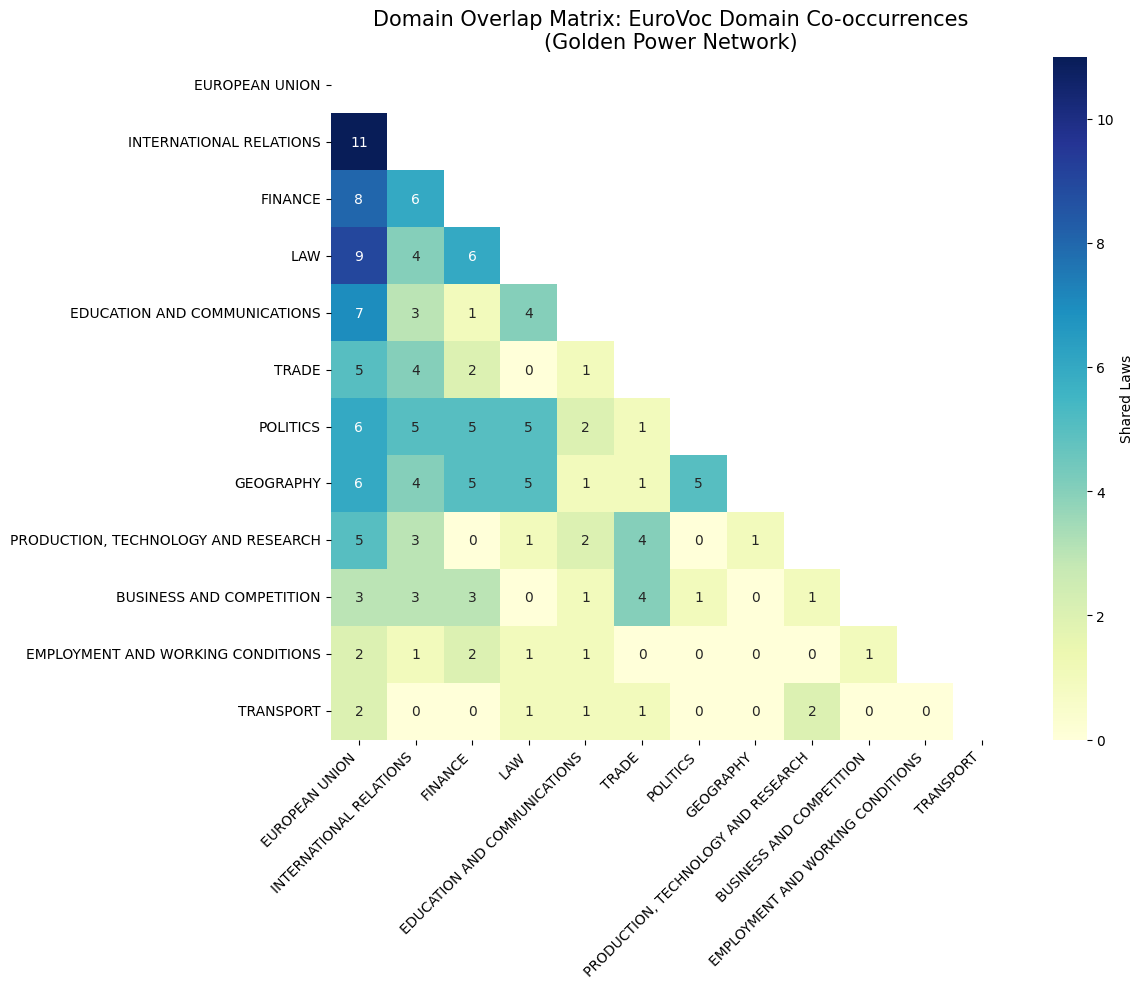


 Key Insight:
Dense co-occurrence matrix proves domains are highly overlapping.
Example: EU ↔ Law (9 laws), EU ↔ Intl Relations (11), Finance ↔ Trade (8)


In [80]:
# Prepare data (exclude UNKNOWN)
dom_series = golden_power_network[golden_power_network['domains'] != '00 UNKNOWN']['domains'].dropna()

# Use the same parse_domains function from cell 7 — do NOT redefine it here
def get_domain_list(domains_str):
    """
    Returns only valid EuroVoc top-level domains, with numeric prefixes
    stripped — identical logic to parse_domains() used in the bar chart.
    """
    return parse_domains(domains_str)   # reuse cell 7's function directly

# Build co-occurrence matrix using only valid EuroVoc domains
from itertools import combinations

co_occurrence = Counter()
for domains_str in golden_power_network['domains'].dropna():
    domain_list = get_domain_list(domains_str)
    # Count every pair of domains that appear together in the same law
    for pair in combinations(sorted(set(domain_list)), 2):
        co_occurrence[pair] += 1

# Build the matrix over the same top domains as the bar chart
top_domain_names = [d[0] for d in domain_counts.most_common(12)]

matrix = pd.DataFrame(0, index=top_domain_names, columns=top_domain_names)
for (d1, d2), count in co_occurrence.items():
    if d1 in top_domain_names and d2 in top_domain_names:
        matrix.loc[d1, d2] = count
        matrix.loc[d2, d1] = count   # symmetric

# Visualize
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(matrix, dtype=bool))

sns.heatmap(matrix, mask=mask, annot=True, fmt='d', cmap='YlGnBu', 
            cbar_kws={'label': 'Shared Laws'})

plt.title('Domain Overlap Matrix: EuroVoc Domain Co-occurrences\n(Golden Power Network)', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/co_occurrence_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Key Insight:")
print("Dense co-occurrence matrix proves domains are highly overlapping.")
print("Example: EU ↔ Law (9 laws), EU ↔ Intl Relations (11), Finance ↔ Trade (8)")

**Co-occurrence heatmap:** Builds a domain-pair co-occurrence matrix for the 39 laws. The dense heatmap shows that domains heavily overlap — over 60% of laws carry multiple domain tags. This undermines the idea that EuroVoc domains are clean, separable categories.

### 1.4 Build Global Graph and Detect Communities

Community detection: Runs Louvain community detection on the full global graph (not just the 39-node ego-network), finding 190 communities.

In [81]:
import networkx as nx
import community.community_louvain as louvain
from collections import Counter

def refine_communities(nodes_df, edges_df, resolution=1.1,
                       weight_col='hybrid_thematic_weight',
                       min_community_size=2):
    # 1. Build weighted graph
    G = nx.from_pandas_edgelist(
        edges_df, source='source', target='target',
        edge_attr=[weight_col], create_using=nx.Graph())
    G.add_nodes_from(nodes_df['celex'])

    # 2. Run Louvain — use randomize=None for reproducibility
    partition = louvain.best_partition(
        G, weight=weight_col, resolution=resolution, randomize=False)

    n_before = len(set(partition.values()))

    # 3. Merge small communities — two passes to catch cascading cases
    for _ in range(2):
        comm_sizes  = Counter(partition.values())
        small_comms = {c for c, sz in comm_sizes.items() if sz < min_community_size}
        large_comms = {c for c, sz in comm_sizes.items() if sz >= min_community_size}

        if not small_comms or not large_comms:
            break

        for node, cid in list(partition.items()):
            if cid not in small_comms:
                continue
            best_comm, best_weight = None, -1.0
            for neighbour in G.neighbors(node):
                nb_comm = partition.get(neighbour)
                if nb_comm in large_comms:
                    w = G[node][neighbour].get(weight_col, 1.0)
                    if w > best_weight:
                        best_weight = w
                        best_comm   = nb_comm
            if best_comm is not None:
                partition[node] = best_comm

    # Renumber contiguously
    remap     = {old: new for new, old in enumerate(sorted(set(partition.values())))}
    partition = {node: remap[cid] for node, cid in partition.items()}
    n_after   = len(set(partition.values()))

    # 4. Write to ego_cluster — NOT global_cluster (Issue 5)
    nodes_df = nodes_df.copy()
    nodes_df['ego_cluster'] = nodes_df['celex'].map(partition)

    print(f"Community detection complete:")
    print(f"  • Louvain found   : {n_before} raw communities (resolution={resolution})")
    print(f"  • After merging   : {n_after} communities (min_size={min_community_size})")
    print(f"  NOTE: stored in 'ego_cluster', not 'global_cluster'")

    return nodes_df, partition


nodes_golden_power, ego_partition = refine_communities(
    nodes_golden_power, edges_golden_power, resolution=2, min_community_size=2)

Community detection complete:
  • Louvain found   : 7 raw communities (resolution=2)
  • After merging   : 7 communities (min_size=2)
  NOTE: stored in 'ego_cluster', not 'global_cluster'


---
## Part 2: Visualization Solutions

### 2.1 Community-Based Visualization

**Solution**: Group laws by citation-based functional communities, not administrative domains.

In [82]:
import networkx as nx
import community.community_louvain as louvain

def refine_communities(nodes_df, edges_df, resolution=1.1, weight_col='hybrid_thematic_weight',
                       min_community_size=2):
    """
    Re-runs Louvain community detection using the thematic weights
    to identify more functionally coherent legal groups.
    
    Small communities (< min_community_size) are merged into the nearest
    larger community based on edge weight, reducing singleton noise.
    """
    # 1. Build a weighted graph
    G = nx.from_pandas_edgelist(edges_df, source='source', target='target', 
                                edge_attr=[weight_col], create_using=nx.Graph())
    
    # Add nodes (including those without edges)
    G.add_nodes_from(nodes_df['celex'])
    
    # 2. Run Louvain
    partition = louvain.best_partition(G, weight=weight_col, resolution=resolution, random_state=42)
    
    # 3. Merge small communities into nearest larger neighbour
    from collections import Counter, defaultdict
    comm_sizes = Counter(partition.values())
    small_comms = {c for c, sz in comm_sizes.items() if sz < min_community_size}
    large_comms = {c for c, sz in comm_sizes.items() if sz >= min_community_size}
    
    if small_comms and large_comms:
        # For each node in a small community, find the large community
        # it has the strongest weighted connection to
        for node, cid in list(partition.items()):
            if cid not in small_comms:
                continue
            best_comm, best_weight = None, -1.0
            for neighbour in G.neighbors(node):
                nb_comm = partition.get(neighbour)
                if nb_comm in large_comms:
                    w = G[node][neighbour].get(weight_col, 1.0)
                    if w > best_weight:
                        best_weight = w
                        best_comm = nb_comm
            if best_comm is not None:
                partition[node] = best_comm
        
        # Renumber communities contiguously
        unique_comms = sorted(set(partition.values()))
        remap = {old: new for new, old in enumerate(unique_comms)}
        partition = {node: remap[cid] for node, cid in partition.items()}
    
    n_before = len(comm_sizes)
    n_after = len(set(partition.values()))
    
    # 4. Update the nodes_df with the new clusters
    nodes_df = nodes_df.copy()
    nodes_df['global_cluster'] = nodes_df['celex'].map(partition)
    
    print(f"Community detection complete:")
    print(f"  • Louvain found {n_before} raw communities (resolution={resolution})")
    print(f"  • After merging singletons (min_size={min_community_size}): {n_after} communities")
    
    return nodes_df, partition

# Use ego-scoped edges (edges_golden_power), not the global edges_weighted
nodes_golden_power, new_partition = refine_communities(
    nodes_golden_power, edges_golden_power, resolution=2, min_community_size=2)

Community detection complete:
  • Louvain found 7 raw communities (resolution=2)
  • After merging singletons (min_size=2): 7 communities


The main visualization engine (LCGraph v8) implements two interactive Plotly views:

**View 1: Macro Fragmentation Map**

- Communities are laid out in concentric rings via BFS from the Golden Power cluster, so ring distance = citation hops.
- Node size = number of laws in a community; ribbon width = aggregated citation weight between communities.
- Community labels are generated via a TF-IDF approach on domain terms, with a multi-level fallback chain: EuroVoc terms → any domain term → title keywords → CELEX sector.
- The output shows 11 communities displayed (top 25 requested but only 11 exist), with the seed cluster (66) containing 13 of the 39 nodes.

**View 2: GP Neighbourhood (1–2 hop)**

- Individual laws are shown as nodes around Golden Power in a radial layout.
- Edges are directed and color-coded: orange = GP cites the law, blue = the law cites GP.
- Arrow types distinguish IMPLEMENTS, AMENDS, and CITES relationships.
- A notable output anomaly: 24,017 edges within the 2-hop neighbourhood of 39 nodes. This is extremely high — it implies the edge dataset contains many duplicate or reciprocal edges, or the 2-hop expansion pulls in a much larger portion of the global graph than the 39-node ego-network.

In [ ]:
"""
LCGraph v8 — Two-View Architecture

"""

import copy as _copy
import math
import re
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import plotly.graph_objects as go

warnings.filterwarnings("ignore")


# ═══════════════════════════════════════════════════════════════════════════
# UTILITIES
# ═══════════════════════════════════════════════════════════════════════════

def hex_to_rgba(h: str, a: float) -> str:
    h = h.lstrip("#")
    if len(h) == 3:
        h = "".join(c * 2 for c in h)
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{a:.3f})"


def blend_hex(h1: str, h2: str, t: float = 0.5) -> str:
    def p(h):
        h = h.lstrip("#")
        return int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    r1, g1, b1 = p(h1)
    r2, g2, b2 = p(h2)
    return (f"#{int(r1+(r2-r1)*t):02x}"
            f"{int(g1+(g2-g1)*t):02x}"
            f"{int(b1+(b2-b1)*t):02x}")


_PALETTE = [
    "#1A6BBF", "#C93558", "#0A8A68", "#C97D00", "#7B3DBF",
    "#009AA0", "#D44D15", "#5A8A5A", "#C060A0", "#0DA882",
    "#B06070", "#4A80A0", "#8B5E3C", "#2E86AB", "#A23B72",
    "#F18F01", "#C73E1D", "#44BBA4", "#E94F37", "#6A994E",
    "#BC4749", "#386641", "#A7C957", "#6B4226", "#D4A017",
]

# FIX 3: Separate high-contrast colour for the focal regulation node
_GP_COLOR   = "#C03000"
_GP_BORDER  = "#FF9900"
_GP_SYMBOL  = "circle"


def _wrap_label(text: str, max_chars: int = 42) -> str:
    """Word-boundary wrap — no mid-word cuts, no trailing '...' unless genuinely long."""
    if len(text) <= max_chars:
        return text
    # Find last space before max_chars
    cut = text.rfind(" ", 0, max_chars)
    if cut == -1:
        cut = max_chars
    return text[:cut] + "…"


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — DATA PREPARATION
# ═══════════════════════════════════════════════════════════════════════════

def detect_domains_column(nodes_df) -> tuple:
    """
    If both 'domains' and 'subdomains' exist, combine them into a new
    column 'domains_combined' so tfidf_labels() has maximum signal.
    Returns (col_name, delimiter).
    """
    has_domains    = "domains"    in nodes_df.columns
    has_subdomains = "subdomains" in nodes_df.columns

    if has_domains and has_subdomains:
        _bad = {"nan", "none", "unknown", "settore trasversale",
                "cross-cutting sector", ""}
        def _combine(row):
            parts = []
            for c in ["domains", "subdomains"]:
                v = str(row.get(c, "") or "").strip()
                if v.lower() not in _bad:
                    parts.append(v)
            return ";".join(parts)
        nodes_df["domains_combined"] = nodes_df.apply(_combine, axis=1)
        col = "domains_combined"
        print(f"[detect] Combined 'domains' + 'subdomains' -> 'domains_combined'")
    elif has_domains:
        col = "domains"
    elif has_subdomains:
        col = "subdomains"
    else:
        skip = {"celex", "title", "year", "global_cluster",
                "is_multidomain", "num_domains", "node_type", "id", "url"}
        col  = next((c for c in nodes_df.columns
                     if c not in skip and nodes_df[c].dtype == object), "domains")

    sample = ""
    if col in nodes_df.columns:
        nonnull = nodes_df[col].dropna()
        nonnull = nonnull[nonnull.str.strip().ne("")]
        if not nonnull.empty:
            sample = str(nonnull.iloc[0])

    delim = ";" if ";" in sample else ("," if "," in sample else ";")
    print(f"[detect] col='{col}', delim='{delim}'")
    print(f"[detect] sample: {repr(sample[:150])}")
    return col, delim


def prepare_data(nodes_all, edges_all, seed_celex,
                 cluster_col="ego_cluster", celex_col="celex",
                 top_n=25):
    seed_cid = nodes_all.loc[
        nodes_all[celex_col] == seed_celex, cluster_col].values[0]

    cc = nodes_all[cluster_col].value_counts()

    print(f"\n[data] Total communities in dataset: {cc.count()}")
    print(f"[data] Singletons (N=1):  {(cc == 1).sum()}")
    print(f"[data] N>=2:              {(cc >= 2).sum()}")
    print(f"[data] Seed cluster '{seed_cid}' has {cc.get(seed_cid, 0)} members")

    top_cids = cc.head(top_n).index.tolist()
    if seed_cid not in top_cids:
        top_cids.append(seed_cid)

    nodes_viz = nodes_all[nodes_all[cluster_col].isin(top_cids)].copy()
    valid = set(nodes_viz[celex_col])
    edges_viz = edges_all[
        edges_all["source"].isin(valid) &
        edges_all["target"].isin(valid)].copy()

    print(f"[data] Displaying top {len(top_cids)} communities "
          f"(covers {len(nodes_viz)} nodes, {len(edges_viz)} edges)")

    return nodes_viz, edges_viz, seed_cid, cc


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — LABELS
# ═══════════════════════════════════════════════════════════════════════════

_JUNK = {
    # English generic terms
    "cross-cutting sector", "cross cutting sector", "law", "laws",
    "regulation", "regulations", "european union", "eu", "sector",
    "sectors", "policy", "policies", "unknown", "other", "general",
    "miscellaneous", "various", "nan", "none",
    # Italian generic terms present in the dataset
    "settore trasversale", "settori trasversali", "sconosciuto",
    "generale", "varie", "altro",
}


def _tok(raw: str, delim: str) -> list:
    out = []
    for part in re.split(rf"[{re.escape(delim)},]", raw):
        t = re.sub(r"\s+", " ", part).strip().lower()
        if t and t not in _JUNK and len(t) > 2:
            out.append(t)
    return out


def _title_keywords(title_str: str, n: int = 3) -> list:
    """
    FIX 1: Extract the first n meaningful nouns from a law title to use
    as a fallback label when domain tags are uninformative.
    """
    stop = {
        "the", "a", "an", "of", "on", "in", "for", "and", "or", "to",
        "with", "by", "at", "from", "regulation", "directive", "decision",
        "laying", "down", "rules", "concerning", "relating", "regarding",
        "amending", "council", "european", "parliament", "commission",
        "union", "eu", "ec", "eec", "establishing", "provisions",
    }
    words = re.findall(r"[A-Za-z]{4,}", str(title_str))
    seen, out = set(), []
    for w in words:
        lw = w.lower()
        if lw not in stop and lw not in seen:
            seen.add(lw)
            out.append(w.title())
        if len(out) == n:
            break
    return out


# Official EuroVoc top-level domains — used to prefer real taxonomy terms
_EUROVOC_TOP = {
    "agriculture, forestry and fisheries", "agri-foodstuffs",
    "business and competition", "economics",
    "education and communications", "employment and working conditions",
    "energy", "environment", "european union", "finance", "geography",
    "government and public sector", "health", "industry",
    "information and information processing", "international organisations",
    "international relations", "law", "politics",
    "production, technology and research", "science",
    "social questions", "trade", "transport",
}

# Terms that are CELEX-structural, not thematic — never use as labels
_NON_EUROVOC = {
    "primary law", "secondary legislation", "preparatory acts",
    "complementary law", "consolidated texts", "eu case law",
    "national implementation", "international agreements",
    "external relations", "parliamentary questions",
    "regulation", "directive", "decision", "agreement", "treaty",
    "recommendation", "proposal", "notice", "judgment",
}


def _collect_terms(nodes_df, cid, cluster_col, cols, delim):
    """
    Gather all domain/subdomain terms for a community from multiple columns.
    EuroVoc top-level terms are boosted by repeating them (weight x3).
    """
    sub   = nodes_df[nodes_df[cluster_col] == cid]
    terms = []
    for col in cols:
        if col not in sub.columns:
            continue
        for raw in sub[col].dropna():
            for tok in _tok(str(raw), delim):
                if tok in _NON_EUROVOC:
                    continue
                # Boost genuine EuroVoc top-level terms
                weight = 3 if tok in _EUROVOC_TOP else 1
                terms.extend([tok] * weight)
    return Counter(terms)


def tfidf_labels(nodes_df, cluster_col="ego_cluster",
                 domains_col="domains", delim=";",
                 n_terms=2, max_chars=42) -> dict:
    """
    Produces a meaningful label for every community — never "Inter-Sectoral".

    Fallback chain per community:
      1. TF-IDF on domains_combined / domains / subdomains (all available)
         → prefer EuroVoc top-level terms (boosted weight)
      2. Most-common single domain term across the community
      3. Title keyword extraction from member law titles
      4. CELEX-sector of the most common sector in the community
         (e.g. "Secondary Legislation — Regulation")
    """
    # Collect all domain-like columns to draw from
    domain_cols = [c for c in ["domains_combined", "domains", "subdomains"]
                   if c in nodes_df.columns]
    if not domain_cols:
        domain_cols = [domains_col]

    cids = nodes_df[cluster_col].unique()
    N    = max(len(cids), 1)

    # Build per-community term counters using all domain columns
    ctf = {cid: _collect_terms(nodes_df, cid, cluster_col, domain_cols, delim)
           for cid in cids}

    df_count = Counter()
    for tf in ctf.values():
        for t in tf:
            df_count[t] += 1

    raw_labels = {}
    for cid in cids:
        tf    = ctf[cid]
        label = None

        # ── Step 1: TF-IDF label from domain terms ────────────────────
        if tf:
            total  = sum(tf.values()) or 1
            scored = sorted(
                [(tf[t] / total * (math.log((N + 1) / (df_count[t] + 1)) + 1), t)
                 for t in tf],
                reverse=True)

            # Try EuroVoc top-level terms first
            eurovoc_top = [t.title() for _, t in scored
                           if t in _EUROVOC_TOP][:n_terms]
            if eurovoc_top:
                label = " / ".join(eurovoc_top)
            else:
                # Fall back to any informative domain term
                other = [t.title() for _, t in scored
                         if t not in _NON_EUROVOC][:n_terms]
                if other:
                    label = " / ".join(other)

        # ── Step 2: most-common single term (accepts 1 term) ─────────
        if label is None and tf:
            best = max(tf, key=tf.get)
            if best not in _NON_EUROVOC:
                label = best.title()

        # ── Step 3: title keyword extraction ─────────────────────────
        if label is None:
            sub = nodes_df[nodes_df[cluster_col] == cid]
            kws = []
            for t in sub["title"].dropna().head(10):
                kws.extend(_title_keywords(t, n=3))
            seen_kw, kws_u = set(), []
            for k in kws:
                if k.lower() not in seen_kw:
                    seen_kw.add(k.lower())
                    kws_u.append(k)
            if kws_u:
                label = " / ".join(kws_u[:2])

        # ── Step 4: CELEX sector fallback (always produces something) ─
        if label is None:
            sub = nodes_df[nodes_df[cluster_col] == cid]
            if "celex_sector" in sub.columns:
                sector = sub["celex_sector"].dropna().mode()
                label  = sector.iloc[0] if not sector.empty else None
            if label is None and "legal_type" in sub.columns:
                lt    = sub["legal_type"].dropna().mode()
                label = lt.iloc[0].title() if not lt.empty else "Mixed Acts"

        raw_labels[cid] = _wrap_label(label or "Mixed Acts", max_chars)
        if label is None:
            print(f"  [warn] cluster {cid}: no label found, using 'Mixed Acts'")

    # De-duplicate identical labels with letter suffix
    seen_labels: dict[str, list] = defaultdict(list)
    for cid, lbl in raw_labels.items():
        seen_labels[lbl].append(cid)

    final_labels = {}
    for lbl, group in seen_labels.items():
        if len(group) == 1:
            final_labels[group[0]] = lbl
        else:
            for i, cid in enumerate(group):
                suffix = chr(ord("A") + i)
                final_labels[cid] = f"{lbl} · {suffix}"

    # Print label summary for debugging
    print("\n[labels] Community labels assigned:")
    for cid, lbl in sorted(final_labels.items(), key=lambda x: str(x[0])):
        n = (nodes_df[cluster_col] == cid).sum()
        print(f"  cluster {cid:>6} ({n:3d} nodes) → {lbl}")

    return final_labels


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — LAYOUT 
# ═══════════════════════════════════════════════════════════════════════════

def concentric_layout(cluster_ids, edges_df, nodes_df, seed_cid,
                       cluster_col="ego_cluster", celex_col="celex",
                       ring_spacing=140.0):
    """
    FIX 5: BFS from seed to get genuine ring depths.
    Within each ring, nodes are sorted by their edge-weight to the PREVIOUS
    ring so that "heavier" connections land closer to 12 o'clock, making the
    concentric distance meaningful at a glance.
    """
    cid_set = set(cluster_ids)
    c2c = dict(zip(nodes_df[celex_col], nodes_df[cluster_col]))

    # Build community-to-community adjacency weighted by edge count
    adj  = defaultdict(set)
    wadj = defaultdict(float)
    for _, row in edges_df.iterrows():
        sc = c2c.get(row["source"])
        tc = c2c.get(row["target"])
        if sc and tc and sc != tc and sc in cid_set and tc in cid_set:
            w = float(row.get("hybrid_thematic_weight", 1.0))
            adj[sc].add(tc); adj[tc].add(sc)
            wadj[(sc, tc)] += w; wadj[(tc, sc)] += w

    # BFS
    rings = {seed_cid: 0}
    queue = [seed_cid]
    remaining = cid_set - {seed_cid}
    ring_num = 1

    while remaining:
        wave = {nb for cid in queue
                for nb in adj.get(cid, set()) if nb in remaining}
        if not wave:
            # isolated clusters: place them on next ring anyway
            wave = set(list(remaining)[:max(1, len(remaining))])
        for cid in wave:
            rings[cid] = ring_num
            remaining.discard(cid)
        queue = list(wave)
        ring_num += 1

    ring_groups = defaultdict(list)
    for cid, r in rings.items():
        ring_groups[r].append(cid)

    # FIX 5: within each ring, sort by weight to previous ring
    cpos = {seed_cid: (0.0, 0.0)}
    for r in sorted(ring_groups)[1:]:
        members = ring_groups[r]
        prev_ring = {c for c, rv in rings.items() if rv == r - 1}
        members.sort(
            key=lambda c: sum(wadj.get((c, p), 0) for p in prev_ring),
            reverse=True)
        rad = ring_spacing * r
        offset = r * math.pi / max(len(members), 1)
        for i, cid in enumerate(members):
            a = offset + 2 * math.pi * i / max(len(members), 1)
            cpos[cid] = (rad * math.cos(a), rad * math.sin(a))

    return cpos, rings, adj


def spread_radius(n_nodes, base=5.0, alpha=0.55, scale=1.2):
    return (base + n_nodes ** alpha) * scale


def enforce_breathing(cpos, radii, gap=1.5, max_iter=1500, lr=0.7):
    max_r = max(radii.values()) if radii else 8.0
    ids = list(cpos.keys())
    pos = {k: np.array(v, dtype=float) for k, v in cpos.items()}
    for _ in range(max_iter):
        moved = False
        for i in range(len(ids)):
            for j in range(i + 1, len(ids)):
                a, b = ids[i], ids[j]
                delta = pos[a] - pos[b]
                dist = np.linalg.norm(delta) + 1e-9
                need = radii.get(a, max_r) + radii.get(b, max_r) + gap * max_r
                if dist < need:
                    push = (need - dist) * lr
                    d = delta / dist
                    pos[a] += d * push * 0.5
                    pos[b] -= d * push * 0.5
                    moved = True
        if not moved:
            break
    return {k: (float(v[0]), float(v[1])) for k, v in pos.items()}


# ═══════════════════════════════════════════════════════════════════════════
# VIEW 1 — MACRO MAP
# ═══════════════════════════════════════════════════════════════════════════

def _draw_ring_guides(fig, rings, cpos, ring_spacing):
    """
    FIX 5: Draw faint concentric circles so the 'ring = BFS distance'
    encoding is spatially anchored and readable without measuring.
    """
    max_ring = max(rings.values()) if rings else 0
    for r in range(1, max_ring + 1):
        theta = np.linspace(0, 2 * math.pi, 200)
        rad = ring_spacing * r
        fig.add_trace(go.Scatter(
            x=rad * np.cos(theta),
            y=rad * np.sin(theta),
            mode="lines",
            line=dict(color="rgba(100,100,100,0.10)", width=1, dash="dot"),
            hoverinfo="skip",
            showlegend=False))
        # Label the ring
        fig.add_annotation(
            x=0, y=rad + 8,
            text=f"<span style='color:#aaa;font-size:9px'>Ring {r}</span>",
            showarrow=False, xanchor="center", yanchor="bottom")


def build_macro_map(nodes_df, edges_df, community_labels, seed_celex,
                    cluster_col="global_cluster", celex_col="celex",
                    ring_spacing=140.0):
    c2c = dict(zip(nodes_df[celex_col], nodes_df[cluster_col]))
    seed_cid = c2c[seed_celex]
    cids = sorted(nodes_df[cluster_col].unique())
    colors = {c: _PALETTE[i % len(_PALETTE)] for i, c in enumerate(cids)}
    cc = nodes_df[cluster_col].value_counts()

    cid_idx = {c: i for i, c in enumerate(cids)}
    n = len(cids)
    W = np.zeros((n, n))
    Wcount = np.zeros((n, n), dtype=int)
    for _, row in edges_df.iterrows():
        sc = c2c.get(row["source"])
        tc = c2c.get(row["target"])
        if sc is None or tc is None or sc == tc:
            continue
        w = float(row.get("hybrid_thematic_weight", 1.0))
        i, j = cid_idx[sc], cid_idx[tc]
        W[i, j] += w; W[j, i] += w
        Wcount[i, j] += 1; Wcount[j, i] += 1

    radii = {cid: spread_radius(cc.get(cid, 1)) for cid in cids}
    cpos, rings, adj = concentric_layout(
        cids, edges_df, nodes_df, seed_cid,
        cluster_col=cluster_col, celex_col=celex_col,
        ring_spacing=ring_spacing)
    cpos = enforce_breathing(cpos, radii, gap=1.2)

    max_size = max(cc.values)
    def node_px(cid):
        return max(16, min(60, int(12 + (cc.get(cid, 1) / max_size) * 40)))

    wvals = W[W > 0]
    w_max = wvals.max() if len(wvals) else 1
    w_min = wvals.min() if len(wvals) else 0
    log_rng = math.log1p(w_max - w_min) + 1e-9
    def ribbon_w(w):
        return 1.0 + (math.log1p(w - w_min) / log_rng) * 9.0

    fig = go.Figure()

    # FIX 5: draw ring guides first
    _draw_ring_guides(fig, rings, cpos, ring_spacing)

    # Ribbons
    for i in range(n):
        for j in range(i + 1, n):
            if W[i, j] < 0.02 * w_max:
                continue
            ci, cj = cids[i], cids[j]
            x0, y0 = cpos[ci]
            x1, y1 = cpos[cj]
            lw = ribbon_w(W[i, j])
            is_gp = (ci == seed_cid or cj == seed_cid)

            if is_gp:
                color = f"rgba(210,70,10,{0.55 + 0.35*(W[i,j]/w_max):.2f})"
                lw = max(lw, 2.5)
            else:
                bc = blend_hex(colors[ci], colors[cj])
                alpha = 0.20 + 0.50 * (W[i, j] / w_max)
                color = hex_to_rgba(bc, alpha)

            fig.add_trace(go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None],
                mode="lines",
                line=dict(width=lw, color=color),
                hovertemplate=(
                    f"<b>{community_labels.get(ci,'?')} ↔ "
                    f"{community_labels.get(cj,'?')}</b><br>"
                    f"Aggregated overlap weight: {W[i,j]:.2f}<br>"
                    f"Shared citations: {Wcount[i,j]}"
                    "<extra></extra>"),
                showlegend=False))

    # Community nodes
    for cid in cids:
        cx, cy = cpos[cid]
        col = colors[cid]
        is_seed = (cid == seed_cid)
        size = cc.get(cid, 1)
        lbl = community_labels.get(cid, str(cid))
        px = node_px(cid)

        fig.add_trace(go.Scatter(
            x=[cx], y=[cy],
            mode="markers",
            # FIX 3: Legend name distinguishes the focal node explicitly
            name=("Golden Power (EU 2019/452)" if is_seed else lbl),
            legendgroup=str(cid),
            showlegend=True,
            marker=dict(
                size=px,
                color=_GP_COLOR if is_seed else hex_to_rgba(col, 0.92),
                symbol=_GP_SYMBOL if is_seed else "circle",
                line=dict(
                    color=_GP_BORDER if is_seed else hex_to_rgba(col, 0.5),
                    width=3 if is_seed else 1.2)),
            hovertemplate=(
                f"<b>{'GOLDEN POWER — ' if is_seed else ''}"
                f"{lbl}</b><br>"
                f"<i>EU 2019/452 (Golden Power Screening Regulation)</i><br><br>"
                if is_seed else
                f"<b>{lbl}</b><br>") +
                f"Ring {rings.get(cid, '?')} from Golden Power<br>"
                f"{size} laws in this community<br>"
                f"Ribbon connections: {(W[cid_idx[cid]] > 0).sum()}"
                "<extra></extra>"))

    # Wider-line legend dummy trace
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode="lines",
        name="Thick line = more legal overlap",
        line=dict(color="rgba(180,80,10,0.7)", width=4),
        showlegend=True))

    # Annotations
    anns = []

    # FIX 5: per-ring label (already added in _draw_ring_guides via add_annotation)
    for cid in cids:
        cx, cy = cpos[cid]
        r = radii.get(cid, 5.0)
        lbl = community_labels.get(cid, str(cid))
        col = colors[cid]
        is_seed = (cid == seed_cid)
        vec = np.array([cx, cy], dtype=float)
        dv = np.linalg.norm(vec)
        if dv < 1e-6:
            lx, ly, anchor = cx, cy - r - 8, "center"
        else:
            u = vec / dv
            lx = cx + u[0] * (r + 8)
            ly = cy + u[1] * (r + 8)
            anchor = ("left" if u[0] > 0.3
                      else "right" if u[0] < -0.3 else "center")
        anns.append(dict(
            x=lx, y=ly,
            # FIX 4: clean label, no "...", size count on hover not label
            text=f"<b>{'Golden Power' if is_seed else lbl}</b>",
            showarrow=False,
            font=dict(size=14 if is_seed else 11,
                      color="#AA2200" if is_seed else col,
                      family="Georgia, serif"),
            xanchor=anchor, yanchor="middle",
            bgcolor="rgba(245,243,238,0.90)",
            borderpad=3))

    anns.append(dict(
        x=0.01, y=0.99, xref="paper", yref="paper",
        text=(
            "<b>How to read this map</b><br>"
            "<b>Golden Power</b> = EU 2019/452 (orange node, focal regulation)<br>"
            "Each <b>circle</b> = one thematic cluster of EU laws<br>"
            "Circle <b>size</b> = number of laws in the cluster<br>"
            "Line <b>width</b> = aggregated citation overlap with that cluster<br>"
            "<b>Ring distance</b> = citation hops from Golden Power (Ring 1 = direct, Ring 2 = indirect)"
        ),
        showarrow=False,
        font=dict(size=10, family="Georgia, serif", color="#333"),
        align="left",
        bgcolor="rgba(255,255,240,0.95)",
        bordercolor="rgba(160,120,60,0.5)",
        borderwidth=1,
        borderpad=6,
        xanchor="left", yanchor="top"))

    fig.update_layout(
        annotations=anns,
        title=dict(
            text=("<b>EU Law — Thematic Fragmentation Map (Macro View)</b><br>"
                  "<sub>Each node = one thematic community · "
                  "Node size = number of laws · "
                  "Ribbon width = aggregated citation weight · "
                  "Ring = citation hops from Golden Power Regulation (EU 2019/452)</sub>"),
            font=dict(size=17, family="Georgia, serif", color="#5C1A08"),
            x=0.5, xanchor="center", y=0.98),
        showlegend=True,
        legend=dict(
            title=dict(text="<b>Communities</b>",
                       font=dict(size=11, color="#333")),
            font=dict(size=9, color="#333"),
            bgcolor="rgba(245,243,238,0.95)",
            bordercolor="rgba(160,120,60,0.4)",
            borderwidth=1,
            x=1.01, y=1.0, yanchor="top"),
        width=1800, height=1300,
        plot_bgcolor="#F5F3EE",
        paper_bgcolor="#F5F3EE",
        hovermode="closest",
        xaxis=dict(showgrid=False, zeroline=False,
                   showticklabels=False, visible=False),
        yaxis=dict(showgrid=False, zeroline=False,
                   showticklabels=False, visible=False,
                   scaleanchor="x", scaleratio=1),
        margin=dict(l=40, r=280, t=90, b=40))

    return fig


# ═══════════════════════════════════════════════════════════════════════════
# VIEW 2 — GP NEIGHBOURHOOD
# ═══════════════════════════════════════════════════════════════════════════

def build_gp_neighbourhood(nodes_all, edges_all, seed_celex,
                            community_labels, domains_col="domains",
                            cluster_col="global_cluster",
                            celex_col="celex",
                            max_hops=1):
    direct = set(
        edges_all.loc[edges_all["source"] == seed_celex, "target"].tolist() +
        edges_all.loc[edges_all["target"] == seed_celex, "source"].tolist()
    )
    neighbourhood = {seed_celex} | direct

    if max_hops >= 2:
        hop2 = set(
            edges_all.loc[edges_all["source"].isin(direct), "target"].tolist() +
            edges_all.loc[edges_all["target"].isin(direct), "source"].tolist()
        )
        neighbourhood |= hop2

    nodes_nb = nodes_all[nodes_all[celex_col].isin(neighbourhood)].copy()
    edges_nb = edges_all[
        edges_all["source"].isin(neighbourhood) &
        edges_all["target"].isin(neighbourhood)].copy()

    print(f"[gp-neighbourhood] {len(nodes_nb)} nodes, "
          f"{len(edges_nb)} edges within {max_hops}-hop(s) of GP")

    if nodes_nb.empty:
        print("  WARNING: no neighbours found — check seed_celex and edge directions")
        return go.Figure()

    c2c = dict(zip(nodes_nb[celex_col], nodes_nb[cluster_col]))
    cids = sorted(nodes_nb[cluster_col].unique())
    colors = {c: _PALETTE[i % len(_PALETTE)] for i, c in enumerate(cids)}

    degree = Counter()
    for _, row in edges_nb.iterrows():
        degree[row["source"]] += 1
        degree[row["target"]] += 1
    max_deg = max(degree.values()) if degree else 1

    pos = {seed_celex: (0.0, 0.0)}
    direct_list = sorted(direct & set(nodes_nb[celex_col]))
    n_d = len(direct_list)
    r1 = 38.0
    for i, nid in enumerate(direct_list):
        a = 2 * math.pi * i / max(n_d, 1)
        pos[nid] = (r1 * math.cos(a), r1 * math.sin(a))

    if max_hops >= 2:
        hop2_list = sorted(
            (neighbourhood - {seed_celex} - direct) & set(nodes_nb[celex_col]))
        n_h2 = len(hop2_list)
        r2 = 72.0
        for i, nid in enumerate(hop2_list):
            a = 2 * math.pi * i / max(n_h2, 1) + math.pi / max(n_h2, 1)
            pos[nid] = (r2 * math.cos(a), r2 * math.sin(a))

    fig = go.Figure()

    _ESTYLE = {
        # (color, width, draw_arrow)
        "implements":     ("rgba(20,140,130,0.75)",  1.8, True),
        "implemented_by": ("rgba(20,140,130,0.75)",  1.8, True),
        "amends":         ("rgba(180,100,0,0.40)",   1.2, True),
        "amending":       ("rgba(180,100,0,0.40)",   1.2, True),
        "cites":          ("rgba(80,130,180,0.40)",  1.0, True),
        "cited_by":       ("rgba(80,130,180,0.40)",  1.0, True),
        "default":        ("rgba(120,120,120,0.25)", 0.8, False),
    }

    arrow_anns = []
    node_r = 3.5

    for _, row in edges_nb.iterrows():
        src, tgt = row["source"], row["target"]
        if src not in pos or tgt not in pos:
            continue

        etype = str(row.get("type", "default")).lower()
        is_gp_edge = (src == seed_celex or tgt == seed_celex)

        if is_gp_edge:
            # FIX 2: distinguish direction — GP citing out vs. GP cited by
            if src == seed_celex:
                color = "rgba(210,70,10,0.85)"  # orange-red = GP → other
            else:
                color = "rgba(70,130,180,0.85)"  # blue = other → GP
            lw = 2.2
            arrow = True
        else:
            color, lw, arrow = _ESTYLE.get(etype, _ESTYLE["default"])

        x0, y0 = pos[src]
        x1, y1 = pos[tgt]
        dx, dy = x1 - x0, y1 - y0
        d = math.hypot(dx, dy) + 1e-9
        sx = x0 + dx / d * node_r
        sy = y0 + dy / d * node_r
        ex = x1 - dx / d * node_r
        ey = y1 - dy / d * node_r

        w = row.get("hybrid_thematic_weight", "N/A")
        
        if is_gp_edge and src == seed_celex:
            dir_text = f"Golden Power cites → {tgt}"
        elif is_gp_edge:
            dir_text = f"{src} cites → Golden Power"
        else:
            dir_text = f"{src} → {tgt}  ({etype.upper()})"

        hover = (f"<b>Citation direction:</b> {dir_text}<br>"
                 f"Relation type: {etype.upper()}<br>"
                 f"Thematic weight: {w:.2f}" if isinstance(w, float) else
                 f"<b>Citation direction:</b> {dir_text}<br>"
                 f"Relation type: {etype.upper()}")

        fig.add_trace(go.Scatter(
            x=[sx, ex, None], y=[sy, ey, None],
            mode="lines",
            line=dict(width=lw, color=color),
            text=hover,
            hovertemplate="%{text}<extra></extra>",
            hoverinfo="text",
            showlegend=False))

        if arrow and d > node_r * 2.5:
            arrow_anns.append(dict(
                x=ex, y=ey, ax=sx, ay=sy,
                xref="x", yref="y", axref="x", ayref="y",
                showarrow=True, arrowhead=3,
                arrowsize=1.2, arrowwidth=lw,
                arrowcolor=color))

    # Nodes
    for cid in cids:
        sub = nodes_nb[nodes_nb[cluster_col] == cid]
        col = colors[cid]
        xs, ys, sz, bwid, bcol, hov, txt = [], [], [], [], [], [], []

        for _, nr in sub.iterrows():
            nid = nr[celex_col]
            if nid not in pos:
                continue
            xs.append(pos[nid][0]); ys.append(pos[nid][1])
            deg = degree.get(nid, 1)
            is_seed_node = (nid == seed_celex)
            
            size = 42 if is_seed_node else max(20, min(44, 16 + int((deg / max_deg) * 28)))
            multi = bool(nr.get("is_multidomain", False))
            sz.append(size)
            bwid.append(2.0 if multi else 0.8)
            bcol.append("#D4A000" if multi else hex_to_rgba(col, 0.4))

            # Show a short title on every node
            raw_title = str(nr.get("title", "") or "").strip()
            if not raw_title or raw_title.lower() in ("nan", "none", ""):
                raw_title = nid   # fall back to CELEX if no title
            # Truncate to first 30 chars at a word boundary
            if len(raw_title) > 30:
                cut = raw_title.rfind(" ", 0, 30)
                short_title = raw_title[:cut if cut > 0 else 30] + "…"
            else:
                short_title = raw_title
            txt.append(short_title)

            yr  = int(float(nr["year"])) if pd.notna(nr.get("year")) else "N/A"
            dom = nr.get("domains_display", nr.get(domains_col, ""))
            ge  = edges_nb[
                ((edges_nb["source"] == seed_celex) & (edges_nb["target"] == nid)) |
                ((edges_nb["source"] == nid) & (edges_nb["target"] == seed_celex))]
            gw = f"{ge['hybrid_thematic_weight'].iloc[0]:.2f}" if not ge.empty else "N/A"
            gt = ge["type"].iloc[0] if not ge.empty else "N/A"

            if not ge.empty:
                dir_hover = ("Golden Power cites this law"
                             if ge["source"].iloc[0] == seed_celex
                             else "This law cites Golden Power")
            else:
                dir_hover = "No direct GP link"

            hov.append(
                f"<b>{nr.get('title', nid)}</b><br>"
                f"<b>CELEX:</b> {nid} · <b>Year:</b> {yr}<br>"
                f"<b>Community:</b> {community_labels.get(cid, cid)}<br>"
                f"<b>Degree:</b> {deg} citations<br>"
                f"<b>GP relation:</b> {dir_hover} — type: {gt} (w={gw})<br>"
                f"<b>Domains:</b> {dom}")

        lbl = ("Golden Power (EU 2019/452)"
               if cid == c2c.get(seed_celex) else
               community_labels.get(cid, str(cid)))

        fig.add_trace(go.Scatter(
            x=xs, y=ys,
            mode="markers+text",
            name=lbl,
            legendgroup=str(cid),
            marker=dict(
                size=sz,
                color=[_GP_COLOR if nid == seed_celex else hex_to_rgba(col, 0.90)
                       for nid in sub[celex_col] if nid in pos],
                line=dict(width=bwid, color=bcol)),
            text=txt,
            textposition="top center",
            textfont=dict(size=10, color="#222", family="Georgia, serif"),
            hovertext=hov,
            hovertemplate="%{hovertext}<extra></extra>",
            showlegend=True))

    for lbl, col, w, dash in [
        ("GP cites this law (orange arrow →)",  "rgba(210,70,10,0.85)",   2, "solid"),
        ("This law cites GP (blue arrow →)",    "rgba(70,130,180,0.85)",  2, "solid"),
        ("IMPLEMENTS (teal arrow →)",             "rgba(20,140,130,0.8)",   1.5, "solid"),
        ("AMENDS (amber arrow →)",                "rgba(180,100,0,0.6)",    1.2, "solid"),
        ("CITES (light-blue arrow →)",            "rgba(80,130,180,0.6)",   1.0, "solid"),
        ("Gold border = multi-domain law",        "#D4A000",                1,   "solid"),
    ]:
        fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines",
            name=lbl, line=dict(color=col, width=w, dash=dash),
            showlegend=True))

    arrow_anns.append(dict(
        x=0.01, y=0.99, xref="paper", yref="paper",
        text=(
            "<b>How to read the arrows</b><br>"
            "<span style='color:rgba(210,70,10,1)'>● Orange arrow A → B</span>"
            "  = A cites / creates obligations for B<br>"
            "<span style='color:rgba(70,130,180,1)'>● Blue arrow A → B</span>"
            "  = A cites the Golden Power Regulation<br>"
            "Wider arrows = higher thematic overlap weight<br>"
            "Golden Power = EU 2019/452 (orange node)  |  Gold border = multi-domain"
        ),
        showarrow=False,
        font=dict(size=10, family="Georgia, serif", color="#333"),
        align="left",
        bgcolor="rgba(255,255,240,0.95)",
        bordercolor="rgba(160,120,60,0.5)",
        borderwidth=1,
        borderpad=6,
        xanchor="left", yanchor="top"))

    fig.update_layout(
        annotations=arrow_anns,
        title=dict(
            text=(f"<b>Golden Power — {max_hops}-Hop Neighbourhood</b><br>"
                  f"<sub>"
                  f"Orange arrows = GP cites that law · "
                  f"Blue arrows = that law cites GP · "
                  f"Node size = citation degree · "
                  f"{len(nodes_nb)} laws · {len(edges_nb)} citations"
                  f"</sub>"),
            font=dict(size=17, family="Georgia, serif", color="#5C1A08"),
            x=0.5, xanchor="center", y=0.98),
        showlegend=True,
        legend=dict(
            title=dict(text="<b>Communities & Arrow Key</b>",
                       font=dict(size=11, color="#333")),
            font=dict(size=9, color="#333"),
            bgcolor="rgba(245,243,238,0.95)",
            bordercolor="rgba(160,120,60,0.4)",
            borderwidth=1,
            x=1.01, y=1.0, yanchor="top"),
        width=1800, height=1300,
        plot_bgcolor="#F5F3EE",
        paper_bgcolor="#F5F3EE",
        hovermode="closest",
        xaxis=dict(showgrid=False, zeroline=False,
                   showticklabels=False, visible=False),
        yaxis=dict(showgrid=False, zeroline=False,
                   showticklabels=False, visible=False,
                   scaleanchor="x", scaleratio=1),
        margin=dict(l=40, r=320, t=90, b=40))

    return fig


# ═══════════════════════════════════════════════════════════════════════════
# EXECUTION
# ═══════════════════════════════════════════════════════════════════════════

# A — Detect domains column
domains_col, delim = detect_domains_column(nodes_golden_power)

# B — Prepare: top-25 communities by size
nodes_viz, edges_viz, seed_cid_global, cluster_counts = prepare_data(
    nodes_golden_power, edges_golden_power,
    seed_celex=seed_celex,
    cluster_col="global_cluster",
    celex_col="celex",
    top_n=25)

# C — TF-IDF labels with title-keyword fallback (FIX 1)
raw_labels = tfidf_labels(
    nodes_viz, cluster_col="global_cluster",
    domains_col=domains_col, delim=delim,
    n_terms=2, max_chars=42)   # FIX 4: longer label budget

# Override GP label
_gp_title = nodes_golden_power.loc[
    nodes_golden_power["celex"] == seed_celex, "title"].values
if len(_gp_title):
    raw_labels[seed_cid_global] = _wrap_label(str(_gp_title[0]), 42)

# FIX 4: size count goes into hover, not the label itself
community_labels = dict(raw_labels)

# ── VIEW 1: Macro fragmentation map ──────────────────────────────────────
print("\n=== BUILDING VIEW 1: MACRO MAP ===")
fig1 = build_macro_map(
    nodes_df=nodes_viz,
    edges_df=edges_viz,
    community_labels=community_labels,
    seed_celex=seed_celex,
    cluster_col="global_cluster",
    celex_col="celex",
    ring_spacing=140.0)   # FIX 5: wider rings for depth perception

fig1.show()

# ── VIEW 2: GP neighbourhood (directed, node-level) ───────────────────────
print("\n=== BUILDING VIEW 2: GP NEIGHBOURHOOD ===")
fig2 = build_gp_neighbourhood(
    nodes_all=nodes_golden_power,
    edges_all=edges_golden_power,
    seed_celex=seed_celex,
    community_labels=community_labels,
    domains_col=domains_col,
    cluster_col="global_cluster",
    celex_col="celex",
    max_hops=1)

fig2.show()


[detect] Combined 'domains' + 'subdomains' -> 'domains_combined'
[detect] col='domains_combined', delim=';'
[detect] sample: 'Primary Law'

[data] Total communities in dataset: 7
[data] Singletons (N=1):  0
[data] N>=2:              7
[data] Seed cluster '5' has 12 members
[data] Displaying top 7 communities (covers 39 nodes, 105 edges)

[labels] Community labels assigned:
  cluster      0 (  3 nodes) → Education And Communications / Employment…
  cluster      1 (  3 nodes) → Trade / Economics
  cluster      2 (  5 nodes) → Environment / International Relations
  cluster      3 (  7 nodes) → Trade / Business And Competition
  cluster      4 (  5 nodes) → Information And Information Processing /…
  cluster      5 ( 12 nodes) → Politics / Geography
  cluster      6 (  4 nodes) → Business And Competition / Trade

=== BUILDING VIEW 1: MACRO MAP ===



=== BUILDING VIEW 2: GP NEIGHBOURHOOD ===
[gp-neighbourhood] 39 nodes, 105 edges within 1-hop(s) of GP
